In [5]:
import polars as pl
import sys
sys.path.append('..')

from src.models.clustering import load_clusters, CLUSTERS_DIR, load_covariance
from src.models.clustering import load_clusters, CLUSTERS_DIR

dates = sorted([p.stem for p in CLUSTERS_DIR.glob('*.parquet')])
df = load_clusters(dates[-1])
_, symbols_all = load_covariance(dates[-1])

K = df['cluster'].n_unique()
print(f'Date: {dates[-1]}  K={K}\n')
for k in range(K):
    members = df.filter(pl.col('cluster') == k)['symbol'].to_list()
    print(f'Cluster {k} ({len(members)} stocks): {members[:12]}')
    print()

Date: 2024-12-31  K=10

Cluster 0 (18 stocks): ['BXP', 'CBRE', 'CCI', 'DLR', 'FAF', 'FNF', 'HHH', 'ICE', 'IRM', 'NNN', 'RYN', 'SBAC']

Cluster 1 (17 stocks): ['ATO', 'AWK', 'CME', 'CMS', 'CNP', 'COKE', 'ES', 'FE', 'INVH', 'MCO', 'MDLZ', 'PM']

Cluster 2 (9 stocks): ['ADI', 'AMAT', 'AMD', 'AMKR', 'LFUS', 'NVDA', 'OLED', 'ONTO', 'TER']

Cluster 3 (23 stocks): ['ALB', 'AMGN', 'AU', 'CHRD', 'CPNG', 'CVX', 'DAR', 'DVN', 'GLW', 'INSP', 'MTZ', 'NFG']

Cluster 4 (20 stocks): ['AGCO', 'BWA', 'CNH', 'CROX', 'DKS', 'DLTR', 'DV', 'ELF', 'HST', 'LW', 'PENN', 'PINS']

Cluster 5 (22 stocks): ['AFRM', 'BMRN', 'BPOP', 'CHTR', 'DAL', 'DG', 'GEN', 'GILD', 'GME', 'GOOG', 'GOOGL', 'ILMN']

Cluster 6 (20 stocks): ['BFAM', 'BLDR', 'DCI', 'FAST', 'FDX', 'GGG', 'GWRE', 'HAYW', 'LECO', 'MAS', 'MSA', 'MTD']

Cluster 7 (16 stocks): ['AVY', 'CARR', 'CSL', 'DRS', 'ETN', 'GE', 'HEI', 'LDOS', 'LHX', 'MLM', 'RTX', 'SAIC']

Cluster 8 (22 stocks): ['ABBV', 'ALNY', 'AMCR', 'AVTR', 'BRBR', 'BYD', 'CASY', 'CHE', 'CI', 'CSX

In [6]:
import sys
sys.path.append('..')

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import normalized_mutual_info_score
from pathlib import Path
from datetime import datetime

from src.models.covariance import load_covariance, cov2corr
from src.models.clustering import load_clusters, mantegna_dist

plt.rcParams.update({
    'figure.figsize':    (12, 4),
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

CLUSTERS_DIR = Path('../data/processed/clusters')
dates_str    = sorted([p.stem for p in CLUSTERS_DIR.glob('*.parquet')])
dates_dt     = [datetime.strptime(d, '%Y-%m-%d') for d in dates_str]

print(f'{len(dates_str)} cluster files  |  {dates_str[0]} to {dates_str[-1]}')

207 cluster files  |  2007-10-31 to 2024-12-31


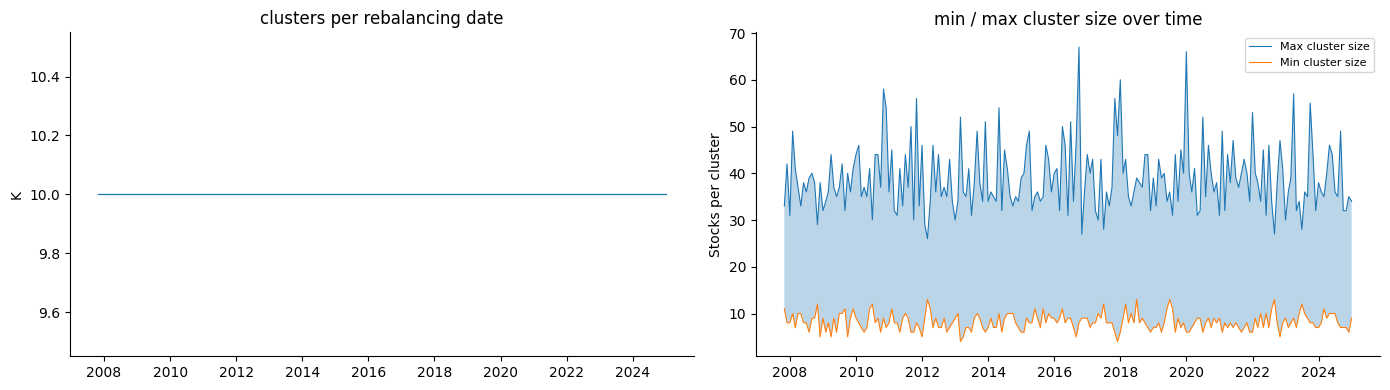

K distribution:
  K=10: 207 dates


In [7]:
ks         = []
max_sizes  = []
min_sizes  = []

for d in dates_str:
    df  = load_clusters(d)
    ks.append(df['cluster'].n_unique())
    szs = df.group_by('cluster').len()['len'].to_list()
    max_sizes.append(max(szs))
    min_sizes.append(min(szs))

ks        = np.array(ks)
max_sizes = np.array(max_sizes)
min_sizes = np.array(min_sizes)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(dates_dt, ks, linewidth=0.9)
axes[0].set_title('clusters per rebalancing date')
axes[0].set_ylabel('K')
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].fill_between(dates_dt, min_sizes, max_sizes, alpha=0.3)
axes[1].plot(dates_dt, max_sizes, linewidth=0.8, label='Max cluster size')
axes[1].plot(dates_dt, min_sizes, linewidth=0.8, label='Min cluster size')
axes[1].set_title('min / max cluster size over time')
axes[1].set_ylabel('Stocks per cluster')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
save_fig("03_clusters_cluster_sizes.png")
plt.show()

print(f'K distribution:')
for k in sorted(set(ks.tolist())):
    print(f'  K={k}: {(ks==k).sum()} dates')

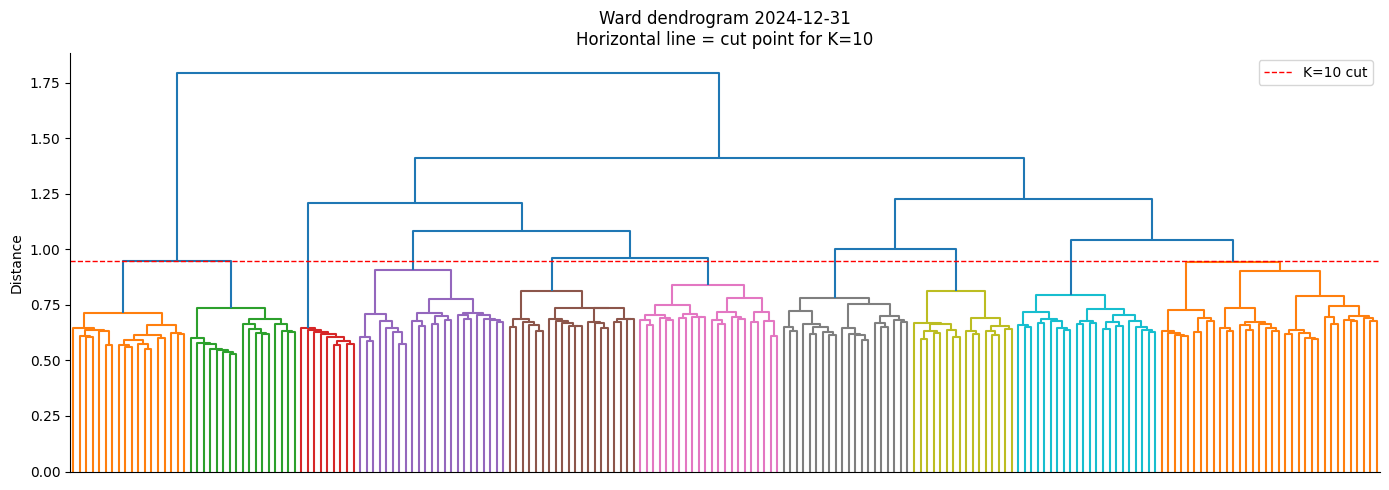

In [8]:
Sigma, symbols = load_covariance(dates_str[-1])
C, _           = cov2corr(Sigma)
D              = mantegna_dist(C)
np.fill_diagonal(D, 0)

Z = linkage(squareform(D, checks=False), method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=Z[-9, 2])
ax.set_title(f'Ward dendrogram {dates_str[-1]}\nHorizontal line = cut point for K=10')
ax.axhline(Z[-9, 2], color='red', linestyle='--', linewidth=1, label='K=10 cut')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
save_fig("03_clusters_dendrogram.png")
plt.show()

NMI between consecutive monthly cluster assignments on the common stock universe.

$$\text{NMI}(A, B) = \frac{2I(A;B)}{H(A)+H(B)} \in [0,1]$$


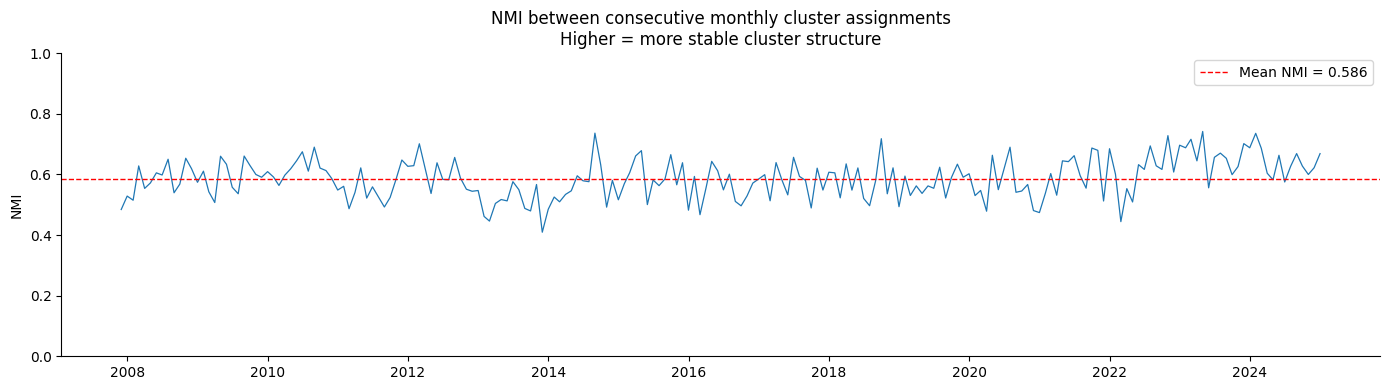

Mean NMI  : 0.5863
Min NMI   : 0.4093  (2013-11-30)
% above 0.5: 90.3%


In [9]:
nmis = []

for i in range(len(dates_str) - 1):
    d1  = load_clusters(dates_str[i])
    d2  = load_clusters(dates_str[i + 1])

    common = set(d1['symbol'].to_list()) & set(d2['symbol'].to_list())
    if len(common) < 10:
        nmis.append(np.nan)
        continue

    l1 = d1.filter(pl.col('symbol').is_in(common)).sort('symbol')['cluster'].to_numpy()
    l2 = d2.filter(pl.col('symbol').is_in(common)).sort('symbol')['cluster'].to_numpy()
    nmis.append(normalized_mutual_info_score(l1, l2))

nmis = np.array(nmis)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_dt[1:], nmis, linewidth=0.9)
ax.axhline(np.nanmean(nmis), color='red', linestyle='--', linewidth=1,
           label=f'Mean NMI = {np.nanmean(nmis):.3f}')
ax.set_title('NMI between consecutive monthly cluster assignments\nHigher = more stable cluster structure')
ax.set_ylabel('NMI')
ax.set_ylim(0, 1)
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
save_fig("03_clusters_nmi.png")
plt.show()

print(f'Mean NMI  : {np.nanmean(nmis):.4f}')
print(f'Min NMI   : {np.nanmin(nmis):.4f}  ({dates_str[1:][np.nanargmin(nmis)]})')
print(f'% above 0.5: {(nmis > 0.5).mean():.1%}')